In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score

In [3]:
df=pd.read_csv(r"C:\Users\HP\Downloads\wine_quality_missing.csv")
df

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34,0.9978,3.51,0.56,9.4,5
5,NaN,0.66,0.02,NaN,0.075,13.0,40,0.9975,3.30,0.60,9.6,5
6,7.9,NaN,0.06,1.6,0.069,15.0,59,NaN,3.39,0.46,10.0,6
7,7.3,0.65,0.00,1.2,0.065,15.0,21,0.9968,3.30,0.65,9.5,5
8,7.8,0.58,NaN,2.0,NaN,9.0,18,0.9970,3.29,0.57,9.8,5
9,7.5,0.50,0.36,6.1,0.071,NaN,29,0.9964,NaN,0.80,10.5,7


In [4]:
df.isna().sum()

fixed_acidity           1
volatile_acidity        1
citric_acid             1
residual_sugar          1
chlorides               1
free_sulfur_dioxide     1
total_sulfur_dioxide    0
density                 1
pH                      1
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [12]:
X=df.drop("quality",axis=1)
y=df["quality"]

In [13]:
y=y.apply(lambda x:1 if x>=7 else 0)

In [14]:
imputer=SimpleImputer(strategy="mean")
X=imputer.fit_transform(X)

In [18]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
model=DecisionTreeClassifier(max_depth=4)

In [21]:
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [26]:
y_pred=model.predict(X_test)

In [27]:
accuracy=accuracy_score(y_test,y_pred)

In [28]:
accuracy

1.0

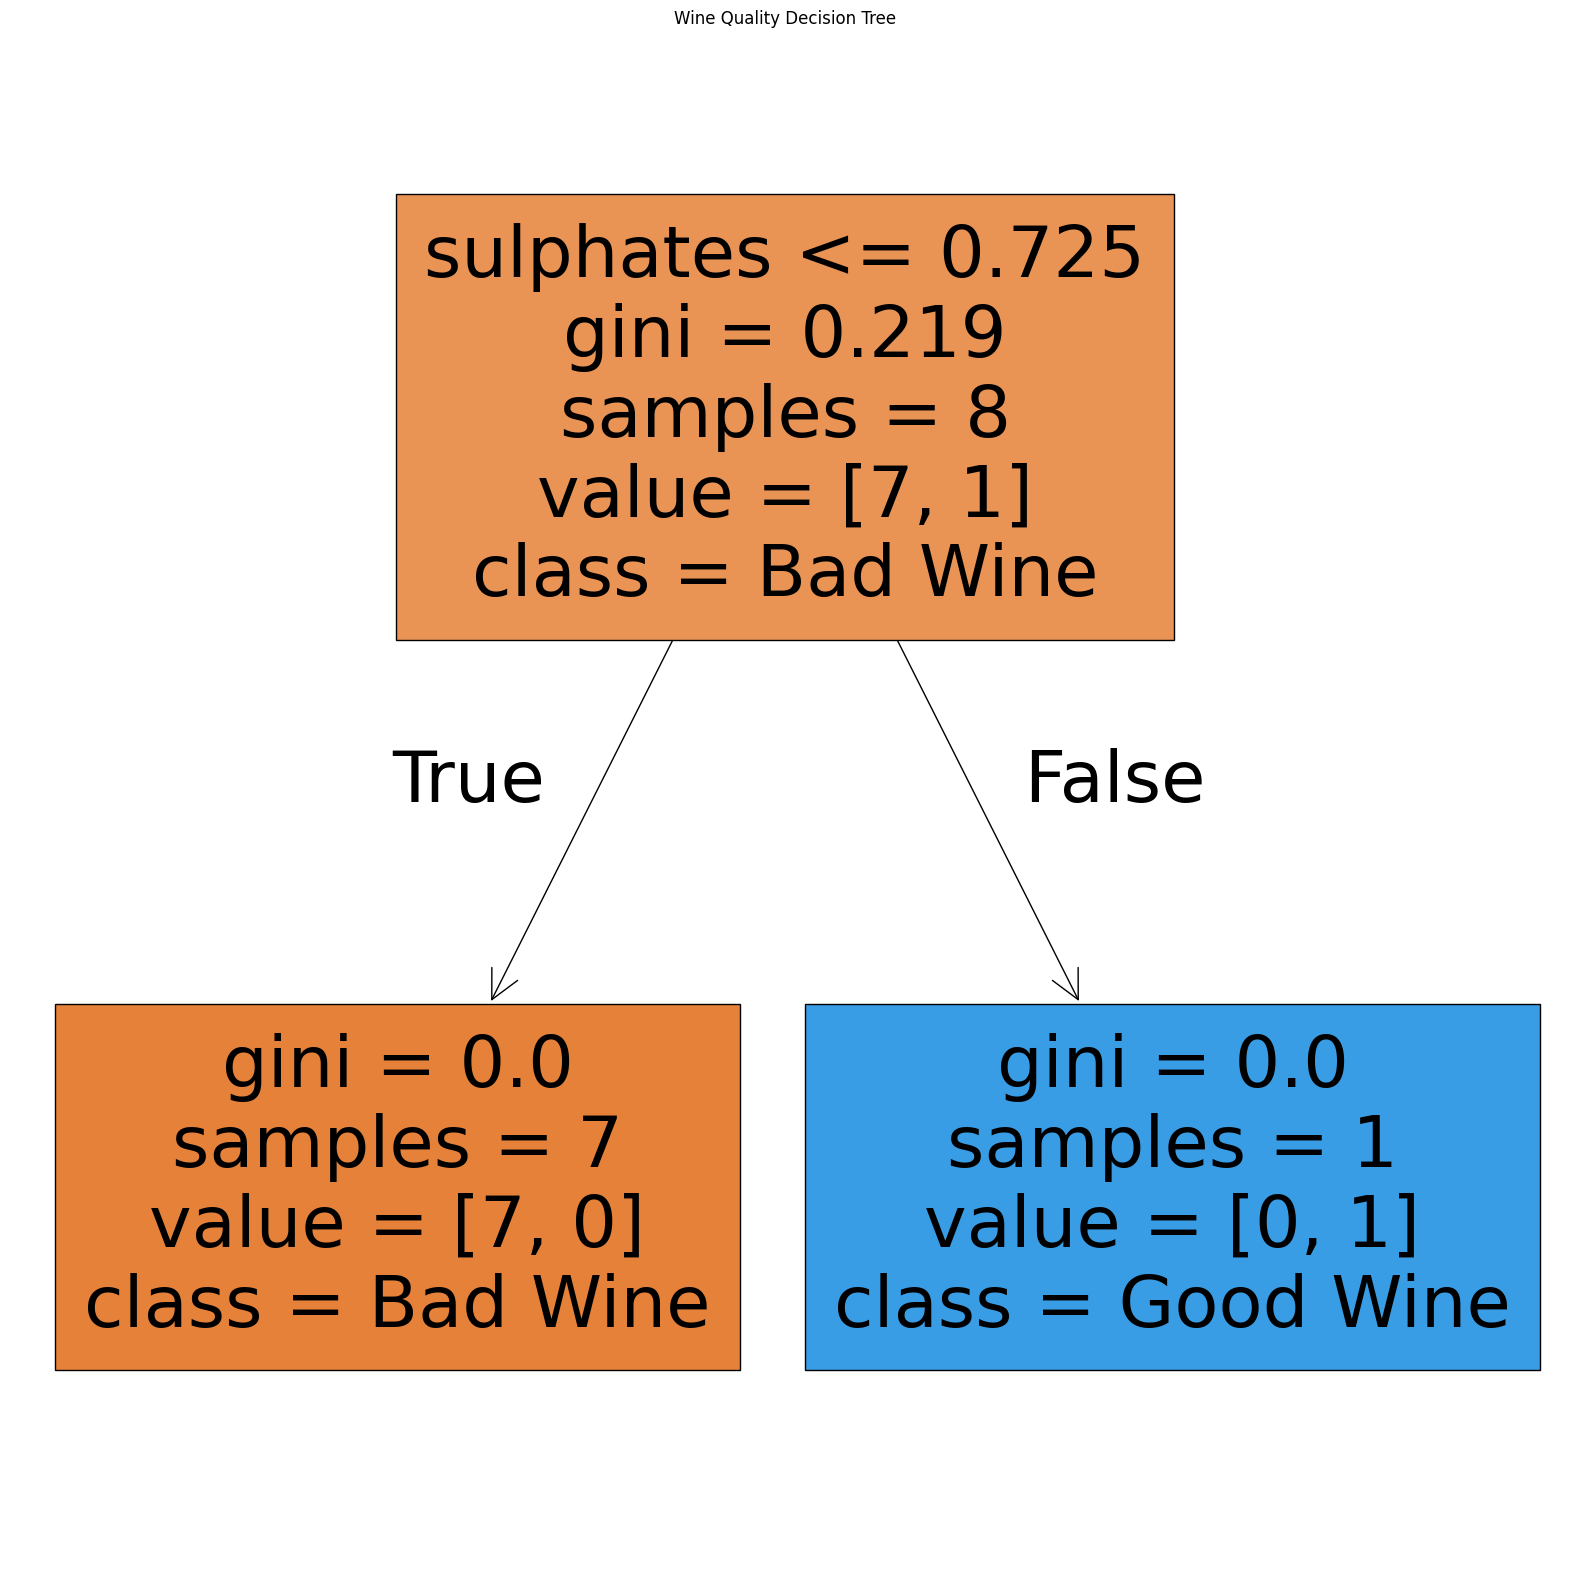

In [31]:
plt.figure(figsize=(20,20))
plot_tree(model,feature_names=df.drop("quality",axis=1).columns,class_names=["Bad Wine","Good Wine"],filled=True)
plt.title("Wine Quality Decision Tree")
plt.show()

In [29]:
model.predict([[6.4,0.72,0.40,1.8,0.1,10.0,35,0.98,3.5,0.5,9.0]])

array([0])

In [30]:
model.predict([[6.4,0.72,0.40,1.8,0.1,10.0,35,0.98,3.5,0.75,9.0]])

array([1])